# Food Delivery Order Analysis — Exploratory Data Analysis (EDA)
**Dataset:** `Order_delivery.csv` — 100,002 food delivery orders across 7 Egyptian cities, including order details, delivery timing, driver info, and geolocation.

**Goal:** Understand what drives delivery performance and order behavior on the platform.
### Questions this analysis aims to answer
1. Which food items and cities generate the most orders and revenue?
2. What is the typical delivery duration, and does traffic level affect it?
3. Which payment methods and vehicle types are most common?
4. Are there outliers in delivery distance or duration that need investigation?
5. How reliable is the delivery process (cancelled vs. delivered orders)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv("Order_delivery.csv")

## 1. Data Overview

In [3]:
df.head(5)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,16-06-2025 08:32,16-06-2025 09:11,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,03-06-2025 21:27,03-06-2025 22:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,01-06-2025 14:48,01-06-2025 15:26,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,13-06-2025 02:30,13-06-2025 03:22,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,06-06-2025 09:48,06-06-2025 10:32,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [4]:
df.shape

(100002, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100002 entries, 0 to 100001
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100002 non-null  int64  
 1   User_ID                    100002 non-null  str    
 2   Restaurant_ID              100002 non-null  int64  
 3   Driver_ID                  100002 non-null  int64  
 4   Item_Name                  100002 non-null  str    
 5   Quantity                   100002 non-null  int64  
 6   Total_Price                100002 non-null  float64
 7   Order_Time                 100002 non-null  str    
 8   Delivery_Time              100002 non-null  str    
 9   Delivery_Duration_Minutes  100002 non-null  int64  
 10  City                       100002 non-null  str    
 11  Payment_Method             100002 non-null  str    
 12  Order_Status               100002 non-null  str    
 13  Driver_Vehicle             100002 non-nu

In [6]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.00000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000,100002.000000
mean,50001.500000,499.832513,250.792414,2.991100,268.922678,37.52021,30.119025,31.063056,30.119070,31.062962,30.119086,31.062983,2.165299
std,28868.235147,288.253044,144.288871,1.410121,170.490102,10.06083,1.271630,0.487763,1.271666,0.487819,1.271690,0.487834,1.038464
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.00000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25001.250000,250.000000,126.000000,2.000000,129.430000,30.00000,30.023110,31.008774,30.023371,31.008460,30.023297,31.008408,1.355612
50%,50001.500000,499.000000,251.000000,3.000000,233.200000,38.00000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75001.750000,750.000000,376.000000,4.000000,381.507500,45.00000,31.026914,31.371673,31.027115,31.371856,31.027242,31.371506,2.924524
max,100002.000000,1000.000000,500.000000,5.000000,750.000000,60.00000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


**Observation:** 100,002 rows and 23 columns. Numeric columns (price, distance, duration) look reasonable — no negative values, and ranges make sense for a food delivery context.

## 2. Data Cleaning

In [7]:
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

**Finding:** No missing values and no duplicate rows — the dataset is already clean on both fronts, so no rows need to be dropped or imputed.

## 3. Item & Revenue Analysis

In [9]:
items_ordered = df.groupby('Item_Name')['Quantity'].sum().sort_values(ascending=False)
print(items_ordered)

Item_Name
Shawarma         33997
Pizza            33778
Fried Chicken    33428
Burger           33250
Koshary          33180
Pasta            32974
Sandwich         32920
Salad            32820
Sushi            32769
Name: Quantity, dtype: int64


In [10]:
revenue_per_item = df.groupby('Item_Name')['Total_Price'].sum().sort_values(ascending=False)
print(revenue_per_item)

Item_Name
Shawarma         3060271.73
Pizza            3026674.63
Fried Chicken    3007307.58
Koshary          2984829.23
Pasta            2982339.18
Burger           2978223.72
Salad            2964643.79
Sandwich         2954850.03
Sushi            2933665.72
Name: Total_Price, dtype: float64


**Finding:** Shawarma has both the highest quantity ordered and the highest total revenue. Note this is *revenue*, not profit — profit would require a cost column, which this dataset doesn't have.

## 4. City-Level Analysis

In [11]:
orders_per_city = df.groupby('City')['Order_ID'].count().sort_values(ascending=False)
print(orders_per_city)

City
Zagazig       14538
Cairo         14382
Tanta         14336
Assiut        14302
Giza          14232
Alexandria    14168
Mansoura      14044
Name: Order_ID, dtype: int64


In [12]:
revenue_per_city = df.groupby('City')['Total_Price'].sum().sort_values(ascending=False)
print(revenue_per_city)

City
Zagazig       3905102.65
Tanta         3896972.63
Cairo         3856412.50
Alexandria    3841624.98
Assiut        3839095.00
Giza          3798249.80
Mansoura      3755348.05
Name: Total_Price, dtype: float64


**Finding:** Zagazig leads in both number of orders and total revenue generated. Order volume is fairly evenly spread across the 7 cities, though — no single city dominates heavily.

## 5. Delivery Duration Analysis

In [13]:
print('Max delivery duration:', df['Delivery_Duration_Minutes'].max(), 'minutes')
print('Min delivery duration:', df['Delivery_Duration_Minutes'].min(), 'minutes')
print('Average delivery duration:', round(df['Delivery_Duration_Minutes'].mean(), 2), 'minutes')

Max delivery duration: 60 minutes
Min delivery duration: 15 minutes
Average delivery duration: 37.52 minutes


**Finding:** Delivery duration ranges from 15 to 60 minutes, averaging around the high-30s. This range looks like a deliberately bounded simulation range rather than raw real-world data.

## 6. Restaurant Analysis

In [14]:
df['Restaurant_ID'].value_counts()

Restaurant_ID
277    133
465    129
114    126
243    126
436    125
      ... 
968     73
877     73
729     73
352     70
592     69
Name: count, Length: 1000, dtype: int64

**Finding:** Restaurant ID 277 receives the most orders (133); restaurant ID 592 receives the fewest (69). The spread across ~1,000 restaurants is fairly even, suggesting no single restaurant dominates demand.

In [15]:
df.groupby(['Restaurant_ID','Item_Name'])['Order_ID'].count()

Restaurant_ID  Item_Name    
1              Burger            9
               Fried Chicken    17
               Koshary          11
               Pasta             6
               Pizza            13
                                ..
1000           Pizza            12
               Salad            10
               Sandwich         15
               Shawarma         11
               Sushi             9
Name: Order_ID, Length: 9000, dtype: int64

## 7. Payment & Vehicle Analysis

In [16]:
df['Payment_Method'].value_counts()

Payment_Method
Cash           33528
Wallet         33251
Credit Card    33223
Name: count, dtype: int64

**Finding:** Cash is the most-used payment method, but only marginally ahead of Wallet and Credit Card — usage is nearly evenly split three ways.

In [17]:
df['Driver_Vehicle'].value_counts()

Driver_Vehicle
Bicycle      33393
Car          33363
Motorbike    33246
Name: count, dtype: int64

**Finding:** Bicycle, Car, and Motorbike are used in almost equal proportion — no single vehicle type dominates deliveries.

## 8. Delivery Distance Analysis

In [18]:
print('Max delivery distance:', round(df['Delivery_Distance_km'].max(), 2), 'km')
print('Min delivery distance:', round(df['Delivery_Distance_km'].min(), 3), 'km')
print('Average delivery distance:', round(df['Delivery_Distance_km'].mean(), 2), 'km')

Max delivery distance: 5.6 km
Min delivery distance: 0.009 km
Average delivery distance: 2.17 km


**Finding:** Deliveries range from 0.009 km to 5.6 km, averaging 2.17 km — consistent with intra-city, short-range food delivery.

## 9. Traffic Level Analysis

In [19]:
df['Traffic_Level'].value_counts()

Traffic_Level
Low       45826
High      29221
Medium    24955
Name: count, dtype: int64

**Finding:** Most deliveries happen under Low traffic conditions, followed by High, then Medium.

### Hypothesis: "Higher traffic level increases delivery duration"Testing this by comparing average delivery duration across traffic levels.

In [20]:
traffic_vs_duration = df.groupby('Traffic_Level')['Delivery_Duration_Minutes'].mean().sort_values()
print(traffic_vs_duration)

Traffic_Level
High      37.450840
Medium    37.486636
Low       37.582726
Name: Delivery_Duration_Minutes, dtype: float64


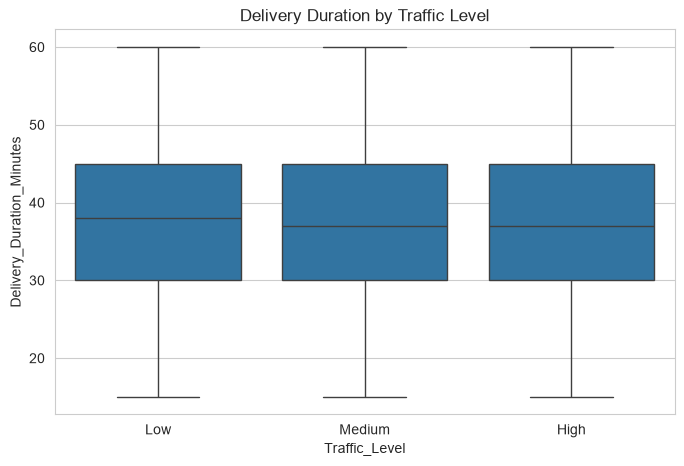

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Traffic_Level', y='Delivery_Duration_Minutes', data=df, order=['Low','Medium','High'])
plt.title('Delivery Duration by Traffic Level')
plt.show()

**Finding — hypothesis rejected:** Average delivery duration barely changes across Low, Medium, and High traffic (all within ~1 minute of each other, roughly 37-38 min). The data does **not** support the assumption that traffic level affects delivery time here — durations were likely generated independently of traffic in this dataset. This is a useful negative finding, not a failure of the analysis.

## 10. Preparing Date/Time Columns

In [22]:
df['Order_Time'] = pd.to_datetime(df['Order_Time'], format='%d-%m-%Y %H:%M')

In [23]:
df['Order_Date'] = df['Order_Time'].dt.date
df['Order_Time'] = df['Order_Time'].dt.time

In [24]:
order_date_col = df.pop('Order_Date')
df.insert(8, 'Order_Date', order_date_col)

In [25]:
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'], format='%d-%m-%Y %H:%M')

In [26]:
df['Delivery_Date'] = df['Delivery_Time'].dt.date
df['Delivery_Time'] = df['Delivery_Time'].dt.time

In [27]:
delivery_date_col = df.pop('Delivery_Date')
df.insert(10, 'Delivery_Date', delivery_date_col)

In [28]:
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Order_Date,Delivery_Time,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,08:32:00,2025-06-16,09:11:00,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,21:27:00,2025-06-03,22:00:00,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,14:48:00,2025-06-01,15:26:00,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,02:30:00,2025-06-13,03:22:00,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,09:48:00,2025-06-06,10:32:00,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


## 11. Visualizations

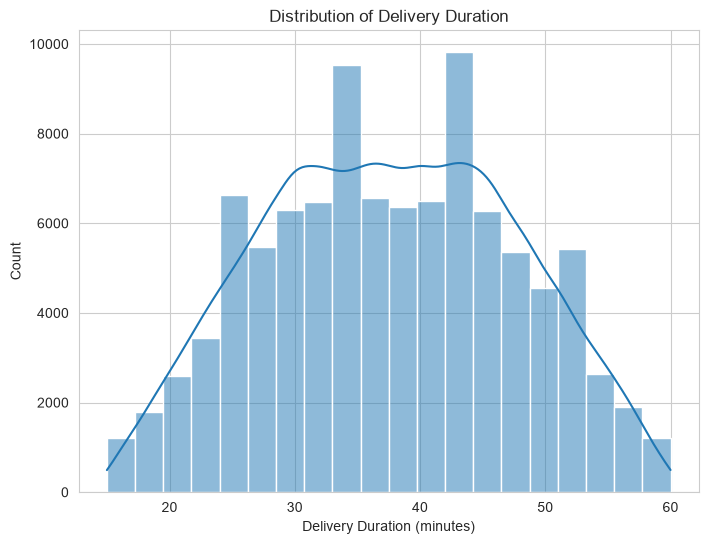

In [29]:
plt.figure(figsize=(8,6))
sns.histplot(df['Delivery_Duration_Minutes'], bins=20, kde=True)
plt.title('Distribution of Delivery Duration')
plt.xlabel('Delivery Duration (minutes)')
plt.show()

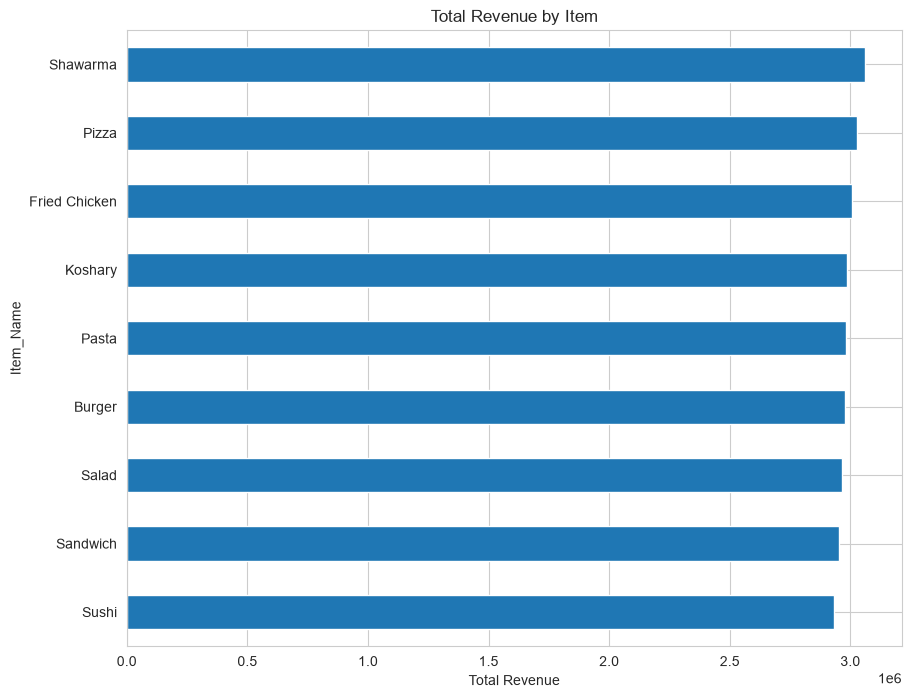

In [30]:
plt.figure(figsize=(10,8))
df.groupby('Item_Name')['Total_Price'].sum().sort_values().plot(kind='barh')
plt.title('Total Revenue by Item')
plt.xlabel('Total Revenue')
plt.show()

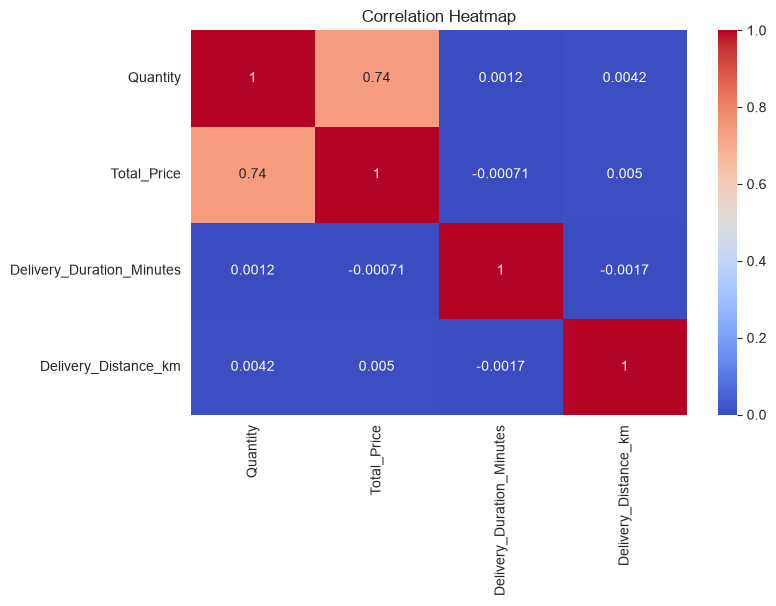

In [31]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Quantity','Total_Price','Delivery_Duration_Minutes','Delivery_Distance_km']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Finding:** None of the numeric variables (quantity, price, duration, distance) show meaningful correlation with each other — all values are close to 0. This suggests these fields were generated independently rather than following real-world relationships (e.g. distance would normally correlate with duration).

## 12. Order Status

Order_Status
Delivered     85199
Cancelled      9812
In Transit     4991
Name: count, dtype: int64


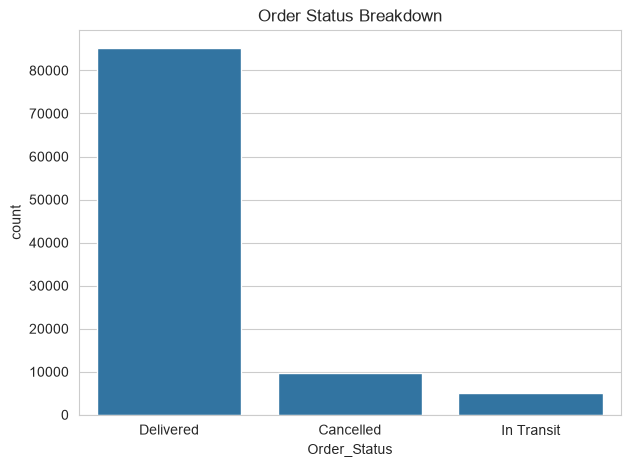

In [32]:
print(df['Order_Status'].value_counts())
plt.figure(figsize=(7,5))
sns.countplot(x='Order_Status', data=df, order=df['Order_Status'].value_counts().index)
plt.title('Order Status Breakdown')
plt.show()

**Finding:** About 85% of orders are marked Delivered, ~10% Cancelled, and ~5% In Transit. A ~10% cancellation rate is worth flagging as an area for the business to investigate further.

## 13. Outlier Detection — Delivery Distance

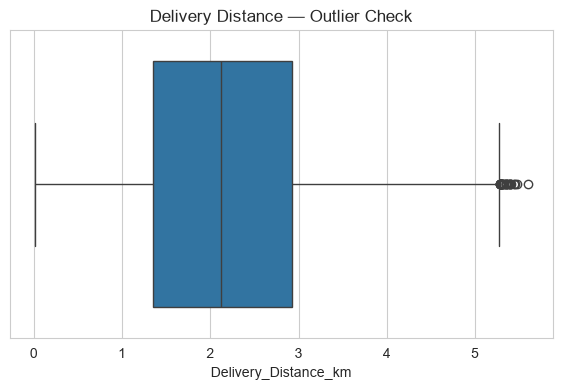

In [33]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['Delivery_Distance_km'])
plt.title('Delivery Distance — Outlier Check')
plt.show()

**Interpretation:** The boxplot flags a handful of points above ~5.3 km as statistical outliers (beyond 1.5×IQR). However, looking at the full range (max = 5.6 km, a normal delivery distance), these aren't erroneous or extreme values — they're just the natural upper tail of a fairly evenly spread (uniform-like) distribution. **Conclusion: not true anomalies**, just the boxplot's standard rule flagging the tail end of a compact range. No cleaning action needed here.

## 14. Outlier Detection — Delivery Duration

In [34]:
q99 = df['Delivery_Duration_Minutes'].quantile(0.99)
outliers = df[df['Delivery_Duration_Minutes'] > q99]
print(f'99th percentile duration: {q99} minutes')
print(f'Number of orders above the 99th percentile: {len(outliers)}')
outliers.head()

99th percentile duration: 58.0 minutes
Number of orders above the 99th percentile: 619


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Order_Date,Delivery_Time,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
580,581,U6560,155,241,Pasta,4,540.92,15:31:00,2025-06-06,16:30:00,...,Bicycle,30.586065,31.506444,30.584595,31.492686,30.572430,31.507731,1.329558,Medium,Offline
640,641,U1935,146,2,Burger,4,245.64,15:51:00,2025-06-03,16:51:00,...,Car,31.180903,29.901761,31.192531,29.930183,31.208282,29.913410,3.000205,Medium,Online
704,705,U4290,635,436,Fried Chicken,3,317.82,13:41:00,2025-06-02,14:41:00,...,Motorbike,31.020435,31.366214,31.036850,31.393286,31.030597,31.398054,3.161154,Medium,Online
1094,1095,U4124,63,127,Sushi,3,344.19,01:41:00,2025-06-13,02:40:00,...,Motorbike,27.170127,31.190226,27.187546,31.190837,27.182564,31.169531,1.931103,Low,Online
1755,1756,U7075,96,287,Pizza,4,565.96,17:36:00,2025-06-07,18:36:00,...,Car,30.056461,31.248524,30.040705,31.238742,30.059509,31.220930,1.985115,High,Online


In [35]:
df.to_csv('Order_Delivery_Updated.csv',index=False)

## 15. Key Findings — Summary
1. **Top performer:** Shawarma leads in both quantity ordered and revenue generated.
2. **City demand:** Zagazig has the highest order count and revenue, but demand is fairly evenly spread across all 7 cities — no single city dominates.
3. **Delivery time:** Averages ~37-38 minutes, ranging from 15 to 60 minutes.
4. **Traffic has no measurable effect** on delivery duration in this dataset — average duration is nearly identical across Low, Medium, and High traffic levels, rejecting the initial hypothesis.
5. **No strong correlations** exist between quantity, price, duration, and distance — these fields appear to vary independently of one another.
6. **Payment and vehicle use** are split almost evenly across their categories (Cash/Wallet/Card, Bicycle/Car/Motorbike).
7. **Order reliability:** ~85% of orders are successfully delivered, but ~10% are cancelled — a metric worth investigating further (e.g. by restaurant or by time of day).
8. **Data quality:** No missing values, no duplicates, and no genuine anomalies in distance or duration — the dataset is clean and ready for further analysis or visualization work.
### Data issues to note- `Total_Price` reflects revenue, not profit (no cost data available).- The lack of correlation between distance and duration suggests this is likely a synthetic/simulated dataset rather than real operational data — worth stating explicitly in any report or video walkthrough.